In [1]:
import pandas as pd

df = pd.read_csv('../data/cs-training.csv', index_col=0)
print(df.isnull().sum())
print(df.dtypes)
print(df.describe())

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
N

In [2]:
df['SeriousDlqin2yrs'].value_counts(normalize=True)

SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64

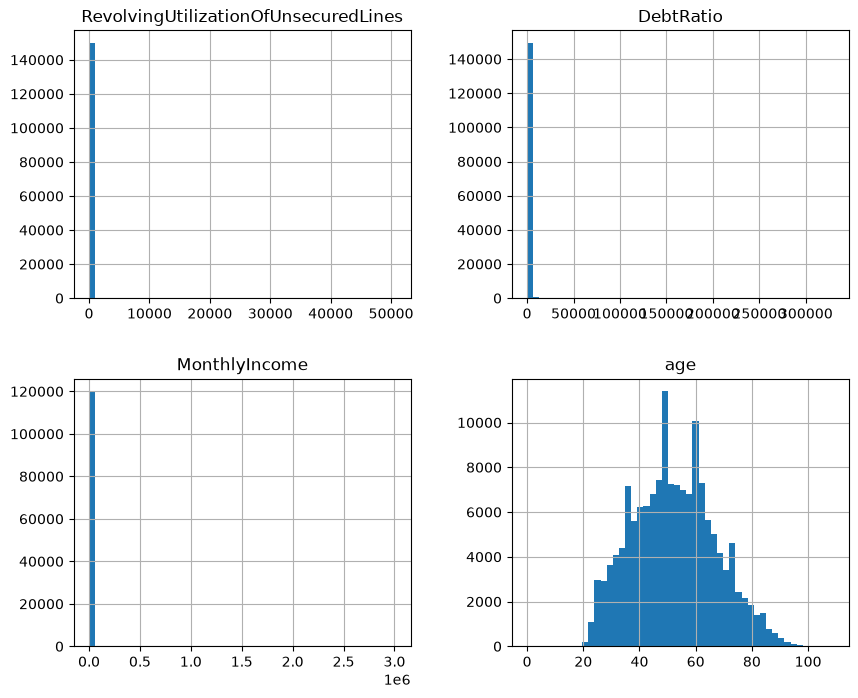

In [3]:
import matplotlib.pyplot as plt
df[['RevolvingUtilizationOfUnsecuredLines','DebtRatio','MonthlyIncome','age']].hist(figsize=(10,8), bins=50)
plt.show()

In [4]:
df['age_group'] = pd.cut(df['age'], bins=[0,25,40,60,120], labels=['<25','25-40','40-60','60+'])
df.groupby('age_group')['SeriousDlqin2yrs'].mean()

age_group
<25      0.111662
25-40    0.102778
40-60    0.072190
60+      0.029960
Name: SeriousDlqin2yrs, dtype: float64

In [5]:
df.corr(numeric_only=True)['SeriousDlqin2yrs'].sort_values(ascending=False)

SeriousDlqin2yrs                        1.000000
NumberOfTime30-59DaysPastDueNotWorse    0.125587
NumberOfTimes90DaysLate                 0.117175
NumberOfTime60-89DaysPastDueNotWorse    0.102261
NumberOfDependents                      0.046048
RevolvingUtilizationOfUnsecuredLines   -0.001802
NumberRealEstateLoansOrLines           -0.007038
DebtRatio                              -0.007602
MonthlyIncome                          -0.019746
NumberOfOpenCreditLinesAndLoans        -0.029669
age                                    -0.115386
Name: SeriousDlqin2yrs, dtype: float64

In [6]:
df.to_csv('../data/cs-training-with-agegroup.csv')